<a href="https://colab.research.google.com/github/sadhanakumble/DemoFirst/blob/main/Gait_GEI_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install timm opencv-python matplotlib scikit-learn



In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import timm

In [4]:
DATASET_PATH = "/content/CASIA-B.zip"

In [5]:
!ls -lh /content/CASIA-B.zip
!file /content/CASIA-B.zip

-rw-r--r-- 1 root root 11M May 30 14:09 /content/CASIA-B.zip
/content/CASIA-B.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [6]:
!unzip -t /content/CASIA-B.zip

Archive:  /content/CASIA-B.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/CASIA-B.zip or
        /content/CASIA-B.zip.zip, and cannot find /content/CASIA-B.zip.ZIP, period.


In [7]:
!file /content/CASIA-B.zip

/content/CASIA-B.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [8]:
!zipinfo /content/CASIA-B.zip


Archive:  /content/CASIA-B.zip
[/content/CASIA-B.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
zipinfo:  cannot find zipfile directory in one of /content/CASIA-B.zip or
          /content/CASIA-B.zip.zip, and cannot find /content/CASIA-B.zip.ZIP, period.


In [9]:
!ls -lh /content/CASIA-B.zip

-rw-r--r-- 1 root root 31M May 30 14:13 /content/CASIA-B.zip


In [10]:
!wget -O /content/GaitDatasetB-silh.zip \
"http://www.cbsr.ia.ac.cn/GaitDatasetB-silh.zip"

--2026-05-30 14:16:03--  http://www.cbsr.ia.ac.cn/GaitDatasetB-silh.zip
Resolving www.cbsr.ia.ac.cn (www.cbsr.ia.ac.cn)... 159.226.21.60
Connecting to www.cbsr.ia.ac.cn (www.cbsr.ia.ac.cn)|159.226.21.60|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 659103200 (629M) [application/x-zip-compressed]
Saving to: ‘/content/GaitDatasetB-silh.zip’

/content/GaitDatase 100%[===================>] 628.57M   267KB/s    in 72m 10s 

2026-05-30 15:28:15 (149 KB/s) - ‘/content/GaitDatasetB-silh.zip’ saved [659103200/659103200]



In [11]:
DATASET_PATH = "/content/GaitDatasetB-silh.zip"

In [20]:
def generate_gei(sequence_folder, image_size=(128,128)):

    images = []

    # Iterate through angle subdirectories (e.g., '000', '018', ... '180')
    for angle_folder_name in sorted(os.listdir(sequence_folder)):
        angle_folder_path = os.path.join(sequence_folder, angle_folder_name)

        if not os.path.isdir(angle_folder_path):
            continue

        # Now iterate through the image files within the angle subdirectory
        for file_name in sorted(os.listdir(angle_folder_path)):
            img_path = os.path.join(angle_folder_path, file_name)

            img = cv2.imread(img_path, 0) # Read as grayscale

            if img is None:
                # print(f"Warning: Could not read image {img_path}")
                continue

            img = cv2.resize(img, image_size)

            # Normalize pixel values to [0, 1]
            img = img / 255.0

            images.append(img)

    if len(images) == 0:
        return None

    # Compute the Gait Energy Image (GEI) by averaging all silhouette images
    gei = np.mean(images, axis=0)

    return gei

In [22]:
import tarfile

X = []
y = []

unzipped_dataset_dir = "/content/GaitDatasetB-silh"

# Ensure the main .zip file is unzipped
if not os.path.exists(unzipped_dataset_dir):
    print(f"Unzipping {DATASET_PATH} to {unzipped_dataset_dir}...")
    !unzip -q $DATASET_PATH -d /content/
    print("Main unzipping complete.")
else:
    print(f"Dataset already unzipped from {DATASET_PATH} at {unzipped_dataset_dir}.")

# The unzipped_dataset_dir now contains .tar.gz files, which need further extraction.
tar_files = sorted([f for f in os.listdir(unzipped_dataset_dir) if f.endswith('.tar.gz')])

# Create a root directory to store all extracted subject folders from tar.gz files
extracted_data_root = "/content/GaitDatasetB_extracted"
os.makedirs(extracted_data_root, exist_ok=True)

# Map original subject identifiers (e.g., '001') to integer labels for y
subject_id_map = {}
next_subject_label = 0

for tar_file_name in tqdm(tar_files, desc="Extracting and processing subject data"):
    tar_file_path = os.path.join(unzipped_dataset_dir, tar_file_name)

    # Extract the subject identifier (e.g., '001' from '001.tar.gz')
    subject_identifier = os.path.splitext(os.path.splitext(tar_file_name)[0])[0]

    # Assign a unique integer label to each subject identifier
    if subject_identifier not in subject_id_map:
        subject_id_map[subject_identifier] = next_subject_label
        next_subject_label += 1
    current_subject_label = subject_id_map[subject_identifier]

    # Define the target directory for extracting this specific tar.gz file
    subject_extracted_path = os.path.join(extracted_data_root, subject_identifier)
    os.makedirs(subject_extracted_path, exist_ok=True) # Ensure this directory exists

    # Extract the tar.gz file
    try:
        with tarfile.open(tar_file_path, "r:gz") as tar:
            tar.extractall(path=subject_extracted_path)
    except tarfile.ReadError as e:
        print(f"Error extracting {tar_file_name}: {e}")
        continue # Skip to the next tar file if extraction fails
    except Exception as e:
        print(f"An unexpected error occurred while extracting {tar_file_name}: {e}")
        continue

    # After extraction, the data structure is usually subject_id/sequence_type/angle/frames
    # The tar file '001.tar.gz' often extracts into a folder '001' inside the target path.
    # So, the actual root for sequences might be subject_extracted_path/subject_identifier.
    actual_subject_data_root = os.path.join(subject_extracted_path, subject_identifier)

    # Verify if the expected inner directory exists, otherwise assume direct extraction
    if not os.path.isdir(actual_subject_data_root):
        actual_subject_data_root = subject_extracted_path

    # Now, iterate through the sequence folders within the actual subject data root
    if os.path.isdir(actual_subject_data_root):
        for sequence_folder_name in os.listdir(actual_subject_data_root):
            sequence_full_path = os.path.join(actual_subject_data_root, sequence_folder_name)

            if os.path.isdir(sequence_full_path): # Check if it's a valid directory (e.g., 'bg-01', 'cl-01', 'nm-01')
                gei = generate_gei(sequence_full_path)

                if gei is not None:
                    X.append(gei)
                    y.append(current_subject_label) # Use the mapped integer label

Dataset already unzipped from /content/GaitDatasetB-silh.zip at /content/GaitDatasetB-silh.


Extracting and processing subject data:   0%|          | 0/124 [00:00<?, ?it/s]/tmp/ipykernel_4575/2090367641.py:46: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=subject_extracted_path)
Extracting and processing subject data: 100%|██████████| 124/124 [15:12<00:00,  7.36s/it]


In [25]:
X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

Dataset Shape: (1240, 128, 128)
Labels Shape: (1240,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
class GaitDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        image = self.X[idx]

        image = np.expand_dims(image, axis=0)

        image = np.repeat(image, 3, axis=0)

        image = torch.tensor(image, dtype=torch.float32)

        label = torch.tensor(self.y[idx], dtype=torch.long)

        return image, label

In [28]:
train_dataset = GaitDataset(X_train, y_train)
test_dataset = GaitDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [29]:
class HybridModel(nn.Module):

    def __init__(self, num_classes):

        super(HybridModel, self).__init__()

        self.backbone = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            num_classes=0
        )

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=1536,
                nhead=8
            ),
            num_layers=2
        )

        self.fc = nn.Linear(1536, num_classes)

    def forward(self, x):

        x = self.backbone(x)

        x = x.unsqueeze(0)

        x = self.transformer(x)

        x = x.squeeze(0)

        x = self.fc(x)

        return x


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [31]:
num_classes = len(np.unique(y))

model = HybridModel(num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

/tmp/ipykernel_4575/155712180.py:13: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [33]:
EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {running_loss:.4f}")

Epoch 1/20, Loss: 288.0038
Epoch 2/20, Loss: 132.3089
Epoch 3/20, Loss: 45.1270
Epoch 4/20, Loss: 12.0453
Epoch 5/20, Loss: 5.7023
Epoch 6/20, Loss: 3.3215
Epoch 7/20, Loss: 2.5601
Epoch 8/20, Loss: 1.6830
Epoch 9/20, Loss: 1.3738
Epoch 10/20, Loss: 1.2162
Epoch 11/20, Loss: 1.0772
Epoch 12/20, Loss: 0.7809
Epoch 13/20, Loss: 0.6909
Epoch 14/20, Loss: 0.6654
Epoch 15/20, Loss: 0.5677
Epoch 16/20, Loss: 0.4383
Epoch 17/20, Loss: 0.3623
Epoch 18/20, Loss: 0.3661
Epoch 19/20, Loss: 0.3686
Epoch 20/20, Loss: 0.2920


In [34]:
model.eval()

predictions = []
ground_truth = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())

        ground_truth.extend(labels.numpy())

In [35]:
accuracy = accuracy_score(
    ground_truth,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.5725806451612904


In [36]:
print(classification_report(
    ground_truth,
    predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.67      1.00      0.80         2
           2       1.00      0.50      0.67         2
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       0.33      0.50      0.40         2
           7       0.50      0.50      0.50         2
           8       1.00      0.50      0.67         2
           9       0.00      0.00      0.00         2
          10       0.40      1.00      0.57         2
          11       1.00      0.50      0.67         2
          12       1.00      1.00      1.00         2
          13       1.00      0.50      0.67         2
          14       0.00      0.00      0.00         2
          15       0.50      1.00      0.67         2
          16       1.00      0.50      0.67         2
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
cm = confusion_matrix(
    ground_truth,
    predictions
)

print(cm)

[[2 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]]


In [38]:
torch.save(
    model.state_dict(),
    "gait_model.pth"
)

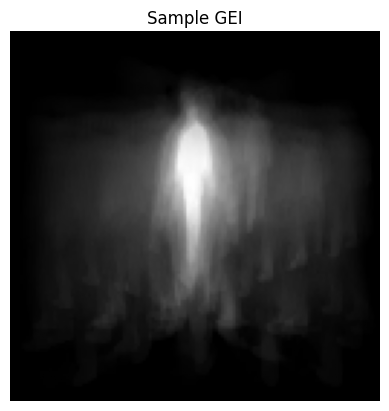

In [39]:
plt.imshow(X[0], cmap='gray')

plt.title("Sample GEI")

plt.axis("off")

plt.show()

In [43]:
print("Number of GEIs:", X.shape[0])
print("Number of classes:", len(np.unique(y)))

Number of GEIs: 1240
Number of classes: 124


In [40]:
import os

print("Subjects:",
      len(os.listdir("/content/GaitDatasetB_extracted")))

print(os.listdir("/content/GaitDatasetB_extracted")[:10])

Subjects: 124
['103', '086', '010', '084', '021', '107', '034', '102', '092', '008']


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
print("/content/GaitDatasetB-silextracted")

/content/GaitDatasetB-silextracted


In [ ]:
!zip -rq /content/GaitDatasetB_extracted.zip /content/GaitDatasetB_extracted

In [ ]:
!ls -lh /content/GaitDatasetB_extracted.zip

In [ ]:
!cp /content/GaitDatasetB_extracted.zip \
"/content/drive/MyDrive/CASIA-B/"

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/CASIA-B"))

In [ ]:
/content/GEI_Images

Step 4: Future sessions

Next time:

from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/CASIA-B/GaitDatasetB_extracted"

No downloading.
No ZIP extraction.
No TAR extraction.